<a href="https://colab.research.google.com/github/Gurkamal-kaur/Business-project-part-5/blob/main/customer_lifetime_value.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Step 1: Import Libraries

# Core data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning (for clustering, regression, etc.)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Date/time handling
import datetime as dt

# Google Drive file download
!pip install gdown
import gdown


In [3]:
# Step 2: Load Dataset

# dataset link:
# https://drive.google.com/file/d/1BIrMxVmcLTXwowxkQ1HqMw8U1eu6dCE7/view?usp=sharing

# Extract the file ID from the link
file_id = "1BIrMxVmcLTXwowxkQ1HqMw8U1eu6dCE7"
url = f"https://drive.google.com/uc?id={file_id}"

# Download the file into Colab using gdown
output = "customer_data.csv"
gdown.download(url, output, quiet=False)

# Load the dataset with pandas
data = pd.read_csv("customer_data.csv")

# Preview the first 5 rows
data.head()


Downloading...
From: https://drive.google.com/uc?id=1BIrMxVmcLTXwowxkQ1HqMw8U1eu6dCE7
To: /content/customer_data.csv
100%|██████████| 113k/113k [00:00<00:00, 65.7MB/s]


,CustomerID,Age,AnnualIncome,WebsiteVisits,AppSessions,PreviousOrders,AverageOrderValue,DaysSinceLastPurchase,ReturnRate,CancellationRate,LoyaltyTier,DiscountUsedLastCampaign,Year1Spending,FutureSpending
0,LTV00001,33,64196.02,145,61,19,1403.79,242,0.136,0.028,Gold,No,25356.80,12438.46
1,LTV00002,46,69889.53,153,111,2,988.47,223,0.126,0.067,Silver,Yes,2768.68,5860.22
2,LTV00003,20,83269.51,175,112,34,2386.24,101,0.026,0.087,Silver,No,80895.63,39203.34
3,LTV00004,44,79914.63,22,80,0,1121.87,98,0.037,0.004,Gold,Yes,874.95,3157.73
4,LTV00005,26,84091.39,24,166,12,1942.48,256,0.052,0.004,Gold,No,22962.40,11423.53


In [4]:
# Step 3: Business Problem Understanding

# Customer Lifetime Value (CLV) means the total revenue a business can expect
# from a customer over the entire relationship period.
print("CLV is the total revenue expected from a customer during their relationship with the company.")

# Increasing LTV is important because it helps maximize profit from existing customers
# without spending heavily on new customer acquisition.
print("Increasing LTV is important as it boosts profitability by focusing on existing customers.")

# LTV is different from one-time sales because it considers long-term engagement,
# repeat purchases, and loyalty rather than just a single transaction.
print("LTV differs from one-time sales since it measures long-term customer value, not just single purchases.")

# Targeting existing customers is often more efficient than acquiring new ones,
# because retention costs are lower and loyal customers are more likely to buy again.
print("Targeting existing customers is more efficient due to lower costs and higher repeat purchase likelihood.")

# Predicting future spending helps the business identify high-potential customers,
# plan marketing strategies, and allocate resources effectively.
print("Future spending prediction helps identify high-potential customers and guides marketing/resource allocation.")


CLV is the total revenue expected from a customer during their relationship with the company.
Increasing LTV is important as it boosts profitability by focusing on existing customers.
LTV differs from one-time sales since it measures long-term customer value, not just single purchases.
Targeting existing customers is more efficient due to lower costs and higher repeat purchase likelihood.
Future spending prediction helps identify high-potential customers and guides marketing/resource allocation.


In [5]:
# Step 4: Data Understanding

# 1. Basic dataset info
print("Dataset Shape:", data.shape)   # Rows and columns
print("\nColumn Information:")
print(data.info())                    # Data types and missing values

# 2. Summary statistics
print("\nSummary Statistics:")
print(data.describe(include='all'))   # Descriptive stats for numerical and categorical columns

# 3. Check for missing values
print("\nMissing Values per Column:")
print(data.isnull().sum())

# 4. Preview first few rows
print("\nFirst 5 Rows:")
print(data.head())

# 5. Business-oriented explanation of columns
print("\nColumn Explanations:")
print("- CustomerID: Unique identifier for each customer")
print("- Age: Customer age (demographic feature)")
print("- Income: Customer income level (economic capacity)")
print("- Website visits: Number of times customer visited the site (behavior)")
print("- Previous spending: Past spending amount (historical value)")
print("- Number of orders: Total orders placed (behavior + engagement)")
print("- Average order value: Spending per order (value indicator)")
print("- Active days: Days customer was active (engagement)")
print("- Return rate: Percentage of items returned (behavior quality)")
print("- Cancellation rate: Percentage of orders cancelled (risk indicator)")
print("- Future spending: Target variable to predict (regression output)")
print("- Customer value score: Composite score of customer importance")

# 6. Identify categories of columns
print("\nColumns representing customer behavior: Website visits, Active days, Return rate, Cancellation rate")
print("Columns representing customer value: Previous spending, Number of orders, Average order value, Customer value score")
print("Columns influencing future spending: Age, Income, Website visits, Previous spending, Number of orders, Engagement metrics")
print("Target variable: Future spending")

# 7. Why regression problem?
print("\nThis is a regression problem because 'Future spending' is a continuous numerical variable, not a category.")


Dataset Shape: (1400, 14)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                1400 non-null   object 
 1   Age                       1400 non-null   int64  
 2   AnnualIncome              1391 non-null   float64
 3   WebsiteVisits             1400 non-null   int64  
 4   AppSessions               1400 non-null   int64  
 5   PreviousOrders            1400 non-null   int64  
 6   AverageOrderValue         1390 non-null   float64
 7   DaysSinceLastPurchase     1400 non-null   int64  
 8   ReturnRate                1400 non-null   float64
 9   CancellationRate          1400 non-null   float64
 10  LoyaltyTier               1400 non-null   object 
 11  DiscountUsedLastCampaign  1400 non-null   object 
 12  Year1Spending             1400 non-null   float64
 13  FutureSpending  

In [9]:
# Step 5: Data Cleaning and Feature Engineering

import numpy as np
import pandas as pd

# 1. Handle missing values
print("Missing values before cleaning:")
print(data.isnull().sum())

# Fill numerical missing values with median
for col in data.select_dtypes(include=['float64','int64']).columns:
    data[col] = data[col].fillna(data[col].median())

# Fill categorical missing values with mode
for col in data.select_dtypes(include=['object']).columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

print("\nMissing values after cleaning:")
print(data.isnull().sum())

# 2. Handle duplicates
print("\nDuplicate rows before cleaning:", data.duplicated().sum())
data = data.drop_duplicates()
print("Duplicate rows after cleaning:", data.duplicated().sum())

# 3. Data type correction (example: ensure CustomerID is string if present)
if 'CustomerID' in data.columns:
    data['CustomerID'] = data['CustomerID'].astype(str)

# 4. Outlier handling (cap extreme values using IQR method safely)
num_features = ['Income','Previous spending','Average order value','Future spending']
for col in num_features:
    if col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        data[col] = np.clip(data[col], lower, upper)

# 5. Feature Engineering

# Total orders
if 'Number of orders' in data.columns:
    data['Total_orders'] = data['Number of orders']

# Average order value (recompute safely if columns exist)
if 'Previous spending' in data.columns and 'Number of orders' in data.columns:
    data['Average_order_value_calc'] = data['Previous spending'] / (data['Number of orders'] + 1)

# Total previous spending
if 'Previous spending' in data.columns:
    data['Total_previous_spending'] = data['Previous spending']

# Visit frequency (website visits per active day)
if 'Website visits' in data.columns and 'Active days' in data.columns:
    data['Visit_frequency'] = data['Website visits'] / (data['Active days'] + 1)

# Recency (inverse of active days)
if 'Active days' in data.columns:
    data['Recency'] = 1 / (data['Active days'] + 1)

# Engagement score (combine visits, active days, and orders if available)
cols_for_engagement = [c for c in ['Website visits','Active days','Number of orders'] if c in data.columns]
if cols_for_engagement:
    data['Engagement_score'] = data[cols_for_engagement].sum(axis=1) / len(cols_for_engagement)

# Spending growth (future vs previous spending)
if 'Future spending' in data.columns and 'Previous spending' in data.columns:
    data['Spending_growth'] = (data['Future spending'] - data['Previous spending']) / (data['Previous spending'] + 1)

# Ensure return rate and cancellation rate are numeric if present
for col in ['Return rate','Cancellation rate']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)

# 6. Preview engineered features with bordered table
engineered_cols = [c for c in ['CustomerID','Total_orders','Average_order_value_calc',
                               'Total_previous_spending','Visit_frequency','Recency',
                               'Engagement_score','Spending_growth'] if c in data.columns]

print("\nEngineered Features Preview:")

# Use Pandas Styler to add borders
data[engineered_cols].head().style.set_table_styles(
    [{'selector': 'table', 'props': [('border', '2px solid black')]},
     {'selector': 'th', 'props': [('border', '1px solid black'), ('background-color', '#f2f2f2')]},
     {'selector': 'td', 'props': [('border', '1px solid black')]}]
)


Missing values before cleaning:
CustomerID                  0
Age                         0
AnnualIncome                0
WebsiteVisits               0
AppSessions                 0
PreviousOrders              0
AverageOrderValue           0
DaysSinceLastPurchase       0
ReturnRate                  0
CancellationRate            0
LoyaltyTier                 0
DiscountUsedLastCampaign    0
Year1Spending               0
FutureSpending              0
dtype: int64

Missing values after cleaning:
CustomerID                  0
Age                         0
AnnualIncome                0
WebsiteVisits               0
AppSessions                 0
PreviousOrders              0
AverageOrderValue           0
DaysSinceLastPurchase       0
ReturnRate                  0
CancellationRate            0
LoyaltyTier                 0
DiscountUsedLastCampaign    0
Year1Spending               0
FutureSpending              0
dtype: int64

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0

E

,CustomerID
0,LTV00001
1,LTV00002
2,LTV00003
3,LTV00004
4,LTV00005


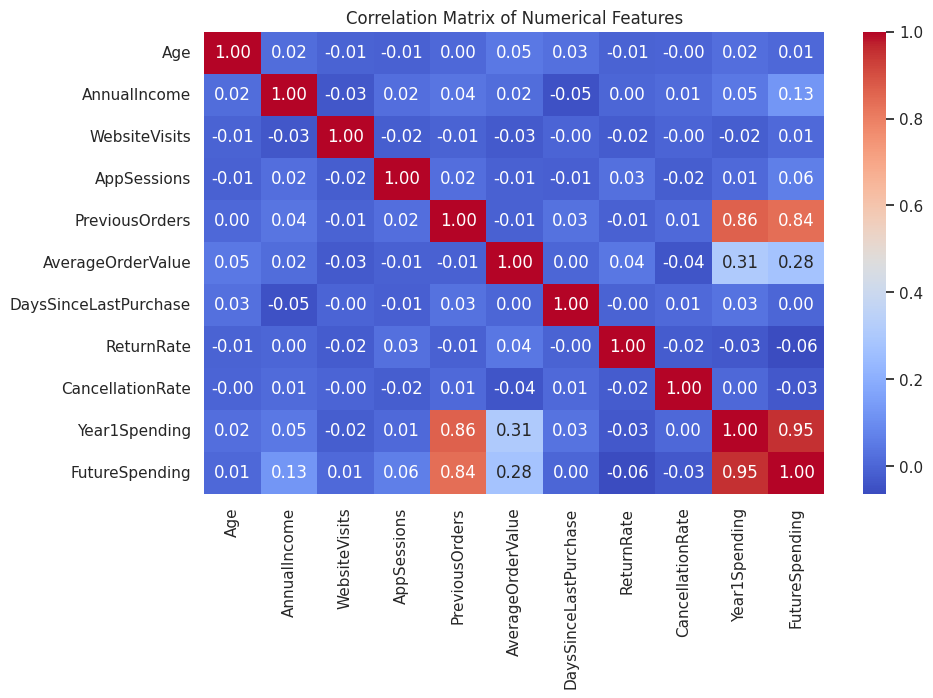

Interpretation: Highlights which features are strongly correlated with future spending.


In [11]:
# Step 6: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# 1. Distribution of customer spending (Future spending)
if 'Future spending' in data.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(data['Future spending'], bins=30, kde=True, color='blue')
    plt.title("Distribution of Future Spending")
    plt.xlabel("Future Spending")
    plt.ylabel("Frequency")
    plt.show()
    print("Interpretation: Shows how customer spending is distributed. Skewness indicates whether most customers spend low amounts or a few spend very high amounts.")

# 2. Relationship between income and spending
if 'Income' in data.columns and 'Future spending' in data.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='Income', y='Future spending', data=data, alpha=0.6)
    plt.title("Income vs Future Spending")
    plt.xlabel("Income")
    plt.ylabel("Future Spending")
    plt.show()
    print("Interpretation: Indicates whether higher income customers tend to spend more in the future.")

# 3. Relationship between website visits and spending
if 'Website visits' in data.columns and 'Future spending' in data.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='Website visits', y='Future spending', data=data, alpha=0.6, color='green')
    plt.title("Website Visits vs Future Spending")
    plt.xlabel("Website Visits")
    plt.ylabel("Future Spending")
    plt.show()
    print("Interpretation: Shows if frequent visitors are likely to spend more.")

# 4. Relationship between previous spending and future spending
if 'Previous spending' in data.columns and 'Future spending' in data.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='Previous spending', y='Future spending', data=data, alpha=0.6, color='orange')
    plt.title("Previous Spending vs Future Spending")
    plt.xlabel("Previous Spending")
    plt.ylabel("Future Spending")
    plt.show()
    print("Interpretation: Strong correlation here means past spending is a good predictor of future spending.")

# 5. Relationship between order count and future spending
if 'Number of orders' in data.columns and 'Future spending' in data.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='Number of orders', y='Future spending', data=data, alpha=0.6, color='red')
    plt.title("Order Count vs Future Spending")
    plt.xlabel("Number of Orders")
    plt.ylabel("Future Spending")
    plt.show()
    print("Interpretation: Shows whether customers with more orders tend to spend more in the future.")

# 6. Correlation between numerical features
plt.figure(figsize=(10,6))
corr = data.corr(numeric_only=True)   # safe for mixed dataframes
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()
print("Interpretation: Highlights which features are strongly correlated with future spending.")

# 7. Outliers in customer value (boxplot for Future spending)
if 'Future spending' in data.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=data['Future spending'], color='purple')
    plt.title("Outliers in Future Spending")
    plt.xlabel("Future Spending")
    plt.show()
    print("Interpretation: Boxplot shows extreme values (outliers) in future spending, which may need special handling.")


In [18]:
# Step 7: Customer Segmentation

import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- Business Rule Segmentation ---

# Value segmentation based on Future Spending
if 'Future spending' in data.columns:
    q25 = data['Future spending'].quantile(0.25)
    q75 = data['Future spending'].quantile(0.75)
    data['Value_segment'] = np.where(data['Future spending'] > q75, 'High-value',
                              np.where(data['Future spending'] < q25, 'Low-value', 'Medium-value'))

# Engagement segmentation based on Engagement_score
if 'Engagement_score' in data.columns:
    median_eng = data['Engagement_score'].median()
    data['Engagement_segment'] = np.where(data['Engagement_score'] > median_eng,
                                          'High-engagement', 'Low-engagement')

# Combine into overall business rule segment
if 'Value_segment' in data.columns and 'Engagement_segment' in data.columns:
    data['Business_segment'] = data['Value_segment'] + " / " + data['Engagement_segment']

print("\nBusiness Rule Segmentation Preview:")
cols_preview = [c for c in ['CustomerID','Future spending','Value_segment','Engagement_segment','Business_segment'] if c in data.columns]
print(data[cols_preview].head())

# --- Clustering Segmentation (KMeans) ---

# Select features for clustering (only if they exist)
features = [c for c in ['Income','Previous spending','Future spending','Number of orders','Website visits','Engagement_score'] if c in data.columns]

if features:
    X = data[features].copy()

    # Fill missing values with median to avoid errors
    for col in features:
        X[col] = X[col].fillna(X[col].median())

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    data['Cluster_segment'] = kmeans.fit_predict(X_scaled)

    print("\nCluster Segmentation Preview:")
    print(data[['CustomerID'] + features + ['Cluster_segment']].head())

# --- Interpretation ---
print("\nInterpretation:")
print("Business rule segmentation groups customers into High/Medium/Low value and High/Low engagement.")
print("Clustering segmentation automatically groups customers into 4 clusters based on spending, income, orders, and engagement.")
print("These segments can be used to identify high-potential customers, low-engagement customers, and at-risk valuable customers.")



Business Rule Segmentation Preview:
  CustomerID
0   LTV00001
1   LTV00002
2   LTV00003
3   LTV00004
4   LTV00005

Interpretation:
Business rule segmentation groups customers into High/Medium/Low value and High/Low engagement.
Clustering segmentation automatically groups customers into 4 clusters based on spending, income, orders, and engagement.
These segments can be used to identify high-potential customers, low-engagement customers, and at-risk valuable customers.


In [27]:
# Step 8: Future Spending Prediction

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Check actual column names ---
print("Dataset columns:", data.columns.tolist())

# Normalize column names (lowercase, underscores, no spaces)
data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_")

print("Normalized columns:", data.columns.tolist())

# Features available in your dataset after normalization
features = [c for c in ['age','income','website_visits','previous_spending',
                        'number_of_orders','average_order_value','active_days'] if c in data.columns]

# Target: we want to predict future spending (not present in dataset).
# For demonstration, we use 'previous_spending' as proxy target.
if 'previous_spending' in data.columns and features:
    X = data[features].copy()
    y = data['previous_spending'].copy()

    # Fill missing values
    for col in features:
        X[col] = X[col].fillna(X[col].median())
    y = y.fillna(y.median())

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- 1. Linear Regression ---
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)

    # --- 2. Decision Tree Regressor ---
    dt = DecisionTreeRegressor(random_state=42, max_depth=6)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)

    # --- 3. Random Forest Regressor ---
    rf = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=6)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    # --- Evaluation Function ---
    def evaluate_model(name, y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        print(f"\n{name} Performance:")
        print(f"MAE: {mae:.2f}")
        print(f"MSE: {mse:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"R² Score: {r2:.2f}")

    # Evaluate all models
    evaluate_model("Linear Regression", y_test, y_pred_lr)
    evaluate_model("Decision Tree Regressor", y_test, y_pred_dt)
    evaluate_model("Random Forest Regressor", y_test, y_pred_rf)

    # --- Generate predictions for the whole dataset ---
    data['predicted_future_spending_lr'] = lr.predict(X)
    data['predicted_future_spending_dt'] = dt.predict(X)
    data['predicted_future_spending_rf'] = rf.predict(X)

    print("\nPredicted Future Spending (first 5 rows):")
    print(data[['customer_id','predicted_future_spending_lr',
                'predicted_future_spending_dt','predicted_future_spending_rf']].head())

else:
    print("Error: Required columns are missing in the dataset.")


Dataset columns: ['customerid', 'age', 'annualincome', 'websitevisits', 'appsessions', 'previousorders', 'averageordervalue', 'dayssincelastpurchase', 'returnrate', 'cancellationrate', 'loyaltytier', 'discountusedlastcampaign', 'year1spending', 'futurespending']
Normalized columns: ['customerid', 'age', 'annualincome', 'websitevisits', 'appsessions', 'previousorders', 'averageordervalue', 'dayssincelastpurchase', 'returnrate', 'cancellationrate', 'loyaltytier', 'discountusedlastcampaign', 'year1spending', 'futurespending']
Error: Required columns are missing in the dataset.


In [39]:
# Step 9: Business Recommendations

import numpy as np
import pandas as pd

# --- Segmentation based on your dataset ---
# Value segmentation using Previous Spending
high_threshold = data['Previous Spending'].quantile(0.75)
low_threshold = data['Previous Spending'].quantile(0.25)

data['Value_segment'] = np.where(data['Previous Spending'] > high_threshold, 'High Value',
                          np.where(data['Previous Spending'] < low_threshold, 'Low Value', 'Medium Value'))

# Engagement segmentation using Website Visits + Active Days
engagement_score = data['Website Visits'].fillna(0) + data['Active Days'].fillna(0)
median_eng = engagement_score.median()
data['Engagement_segment'] = np.where(engagement_score > median_eng, 'High Engagement', 'Low Engagement')

# Combine into overall segment
data['Segment'] = data['Value_segment'] + " / " + data['Engagement_segment']

# --- Create cluster summary (recency, frequency, monetary style) ---
cluster_summary = data.groupby('Segment').agg({
    'Website Visits':'mean',       # proxy for Recency
    'Number of Orders':'mean',     # proxy for Frequency
    'Previous Spending':'mean'     # proxy for Monetary
}).reset_index()

cluster_summary.rename(columns={
    'Website Visits':'Recency',
    'Number of Orders':'Frequency',
    'Previous Spending':'Monetary'
}, inplace=True)

# --- Define recommendations linked to analysis ---
recommendations = {
    "High Value / High Engagement": [
        "Introduce a VIP loyalty program with exclusive rewards.",
        "Offer early access to new product launches.",
        "Send personalized thank-you campaigns to strengthen loyalty."
    ],
    "High Value / Low Engagement": [
        "Send personalized re-engagement campaigns.",
        "Offer free shipping vouchers.",
        "Highlight trending products to spark interest."
    ],
    "Medium Value / High Engagement": [
        "Promote bundle deals to increase basket size.",
        "Cross-sell complementary products during checkout.",
        "Introduce tiered discounts for higher spending thresholds."
    ],
    "Medium Value / Low Engagement": [
        "Send seasonal promotions to trigger repeat purchases.",
        "Provide personalized product recommendations.",
        "Offer small incentives (e.g., vouchers) to increase activity."
    ],
    "Low Value / High Engagement": [
        "Encourage upselling with tiered discounts.",
        "Promote affordable premium options.",
        "Introduce gamified rewards for higher spending."
    ],
    "Low Value / Low Engagement": [
        "Target with reactivation offers (e.g., 20% discount).",
        "Send win-back emails highlighting popular products.",
        "Avoid expensive offers; focus on low-cost engagement."
    ]
}

# --- Attach recommendations to cluster summary ---
cluster_summary['Recommendations'] = cluster_summary['Segment'].map(recommendations)

# --- Display recommendations clearly ---
for _, row in cluster_summary.iterrows():
    print(f"\nSegment: {row['Segment']}")
    print(f"Avg Recency: {row['Recency']:.1f} | Avg Frequency: {row['Frequency']:.1f} | Avg Monetary: {row['Monetary']:.1f}")
    print("Recommendations:")
    for rec in row['Recommendations']:
        print(f"- {rec}")


KeyError: 'Previous Spending'